In [9]:
import shap
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [10]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data , housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.15, max_depth=5, random_state=42)
model.fit(X_train, y_train)
columns = X.columns

# Analyse global

La dépendance partielle montre la relation entre une ou plusieurs caractéristiques (features) et la prédiction moyenne du modèle, tout en "neutralisant" l'effet des autres caractéristiques. Elle répond à la question : Comment les prédictions changent-elles en fonction d'une caractéristique donnée, en moyenne ? Cette approche suppose que les caractéristiques sont indépendantes, ce qui n'est pas toujours vrai dans les données réelles. Les interactions entre variables ne sont pas directement visibles.

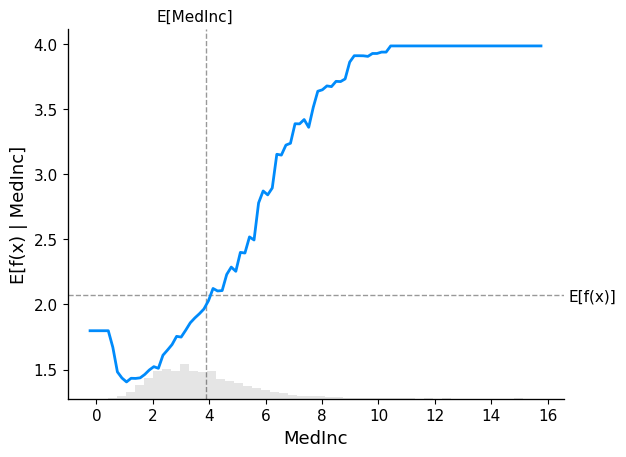

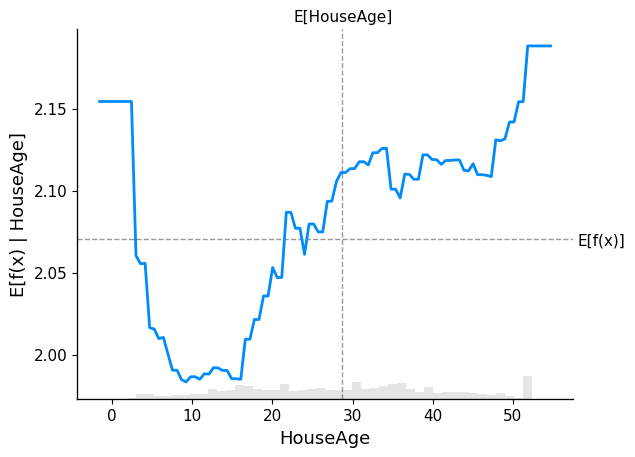

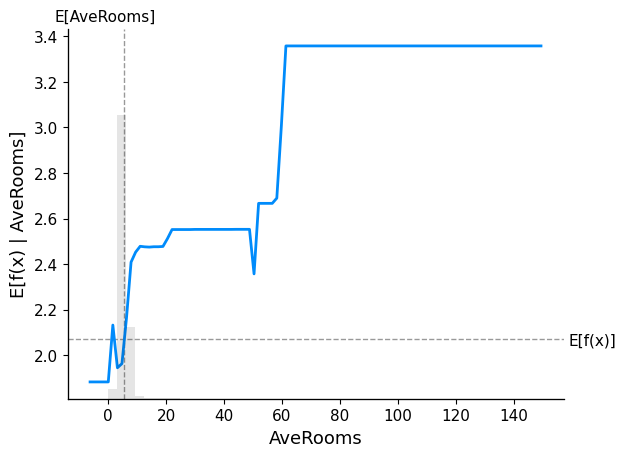

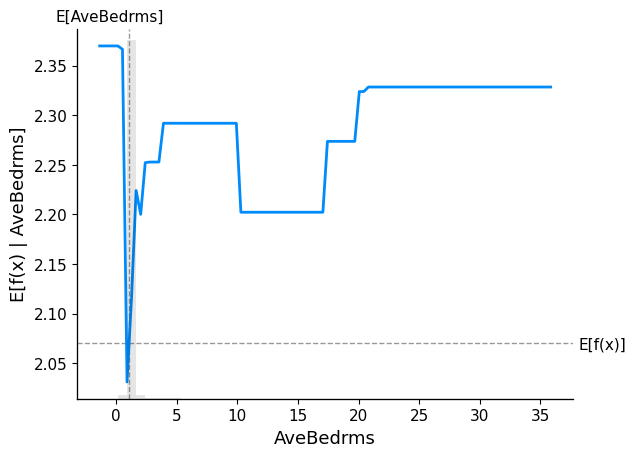

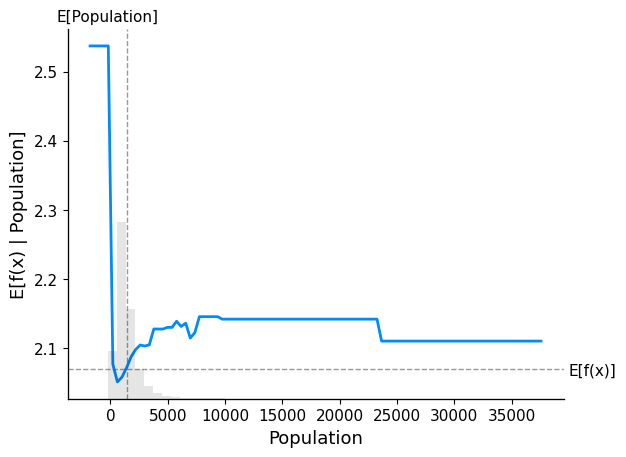

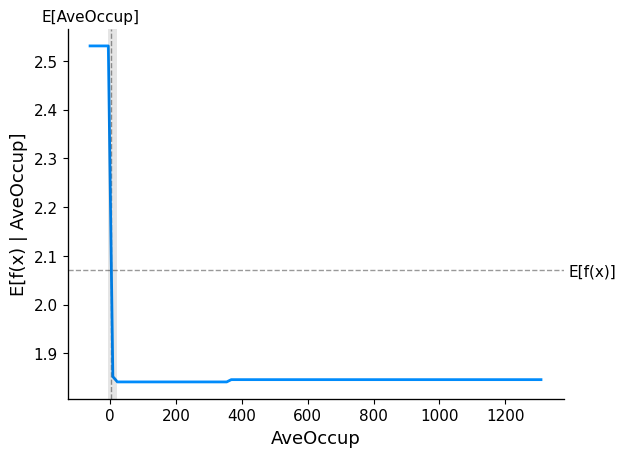

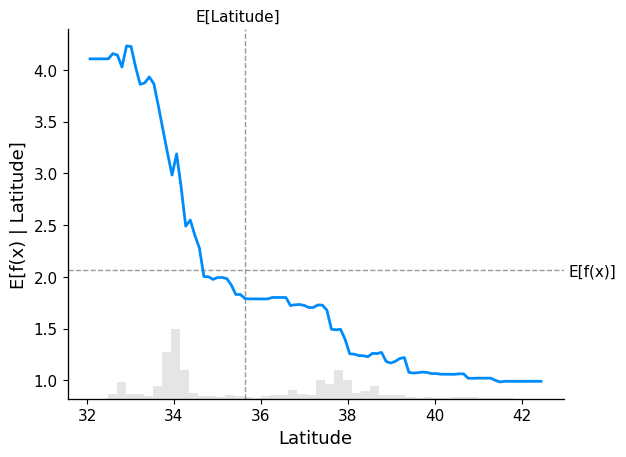

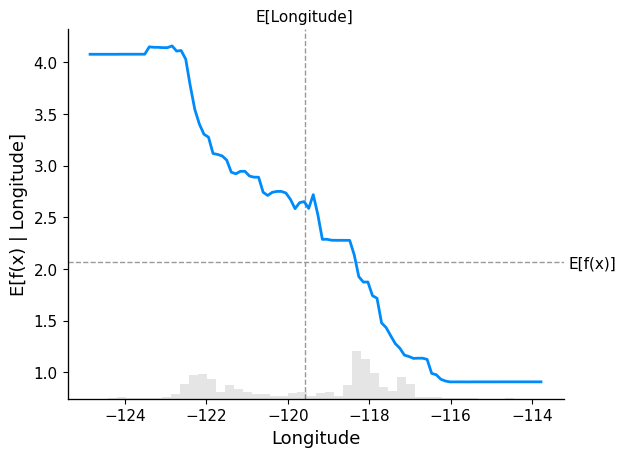

In [11]:
for col in columns:
    shap.partial_dependence_plot(
    col,
    model.predict,
    X,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

MedInc : Valeur des maisons augmente avec le revenu médian.

HouseAge (Relation en U) : maisons récentes plus chères, 5 à 20 ans moins, puis valeur remonte pour maisons anciennes.

AveRooms : Valeur augmente avec le nombre de pièces : 1 à 3 pièces 200000 dollars, 3 à 60 pièces 260000 dollars, plus de 60 pièces 340000 dollars.

AveBedrms : 1 à 10 chambres 230000 dollars, 10 à 17 chambres 220000 dollars, plus de 17 chambres 235000 dollars.

Population : Impact limité, valeur augmente légèrement puis stagne.

AveOccup : Influence négligeable.

Latitude : Valeur diminue en allant vers le nord.

Longitude : Valeur diminue en s’éloignant de la côte californienne.

# Analyse local

Définition :
Les valeurs SHAP mesurent la contribution exacte de chaque caractéristique à la prédiction d'une observation spécifique, en utilisant les valeurs de Shapley issues de la théorie des jeux.

Méthode :
Pour une observation donnée, les valeurs SHAP calculent la différence entre la prédiction obtenue avec et sans chaque caractéristique, en considérant toutes les combinaisons possibles.
Les valeurs SHAP sont additives : la somme des contributions de toutes les caractéristiques est égale à la prédiction finale moins la valeur de base (expected value).

Utilisation :
Explications locales (par observation) et globales (en agrégeant les valeurs SHAP).
Répondre à la question : Pourquoi ce modèle a-t-il fait cette prédiction pour cette observation ?
Exemple :
Pour une observation où la prédiction est élevée, les valeurs SHAP vous diront quelles caractéristiques ont poussé la prédiction à augmenter (et de combien), et lesquelles l'ont fait baisser.

Avantages :
Interactions : Les valeurs SHAP prennent en compte les interactions entre caractéristiques.
Applicables aux explications locales et globales.

ExactExplainer explainer: 4129it [04:03, 16.16it/s]                          


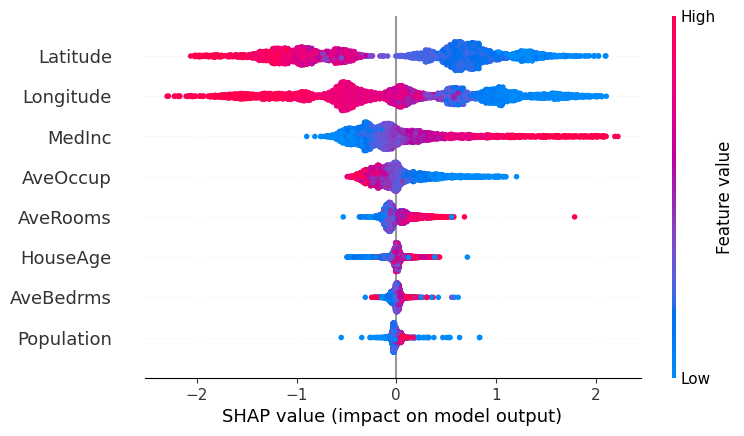

In [12]:
explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

Le graphique des valeurs SHAP présenté ci-dessus confirme les résultats obtenus lors de l'analyse des dépendances partielles. Les variables qui influencent le plus les prédictions du modèle sont **Latitude**, **Longitude**, et **MedInc**. Ces caractéristiques jouent un rôle clé dans la détermination des valeurs médianes des maisons. Ensuite, des variables comme **AveOccup** et **AveRooms** exercent une influence moindre, mais non négligeable. Enfin, **HouseAge**, **Population**, et **AveBedrms** ont une contribution très faible, indiquant qu'elles impactent peu les prédictions du modèle.

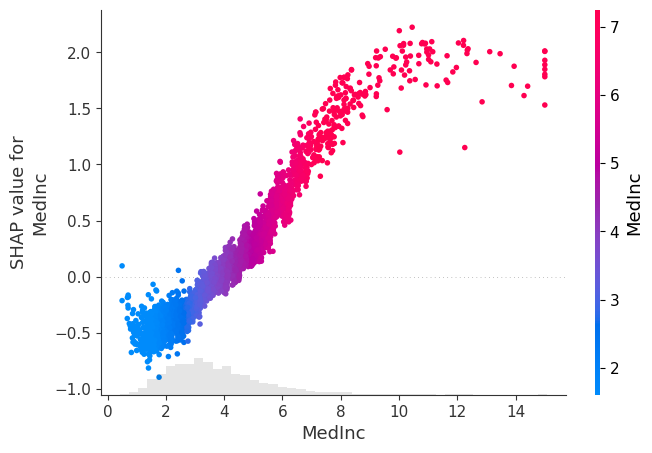

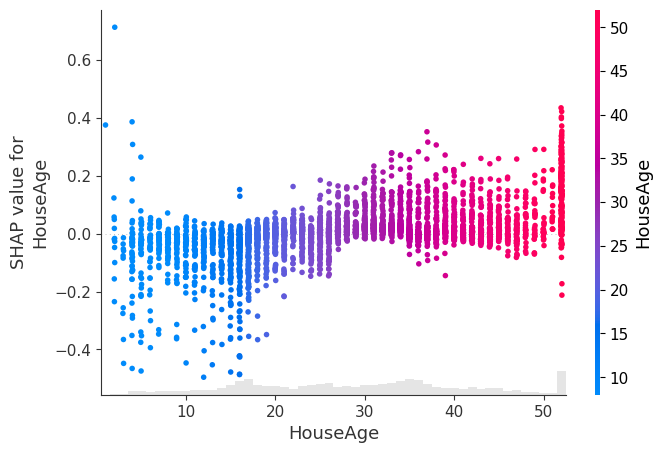

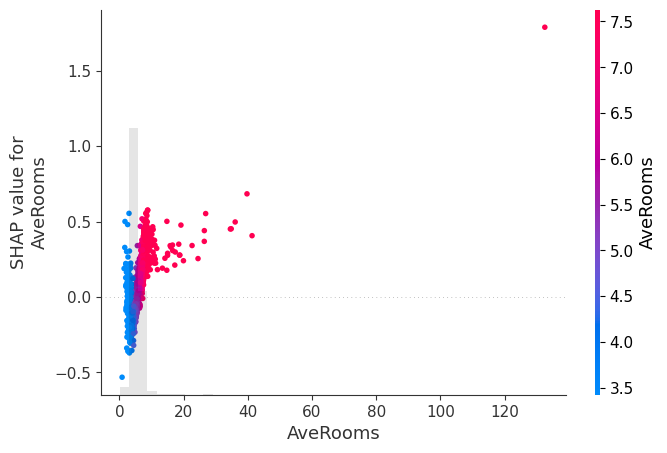

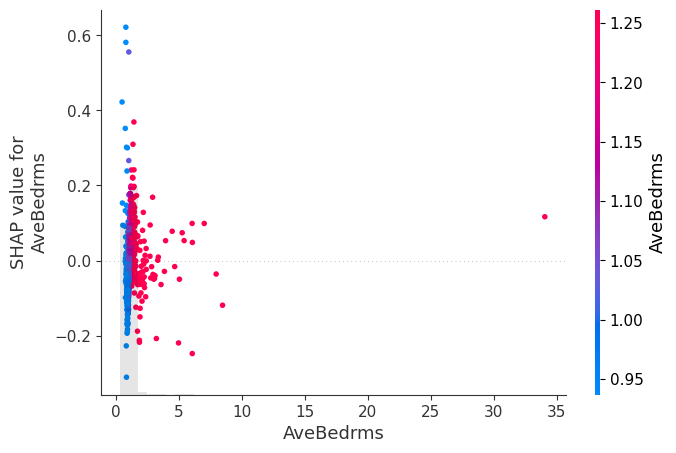

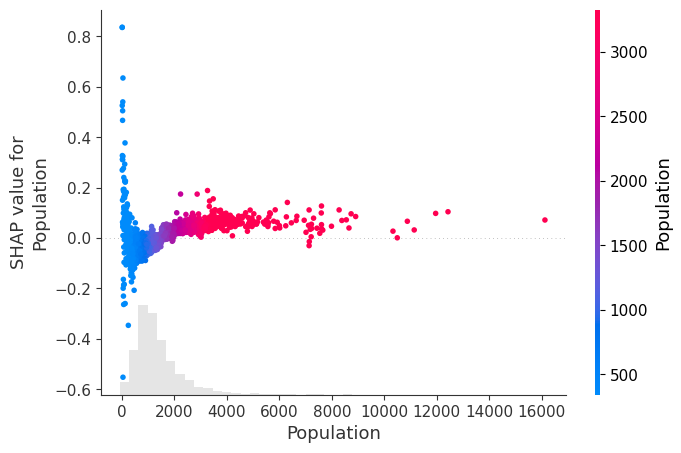

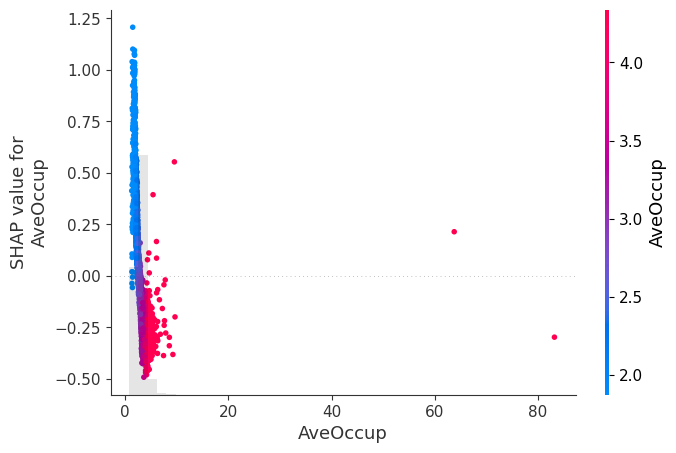

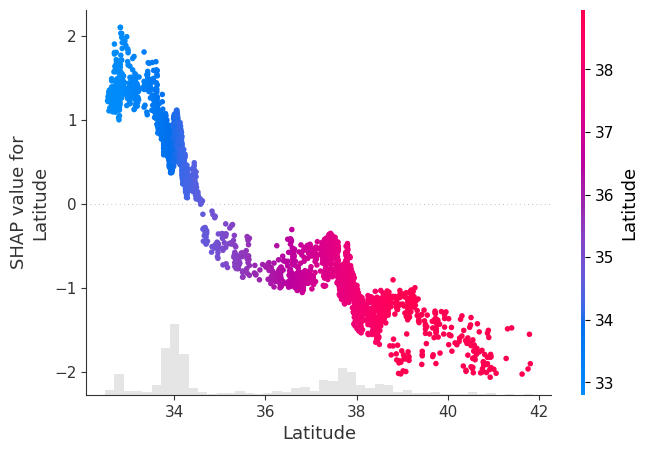

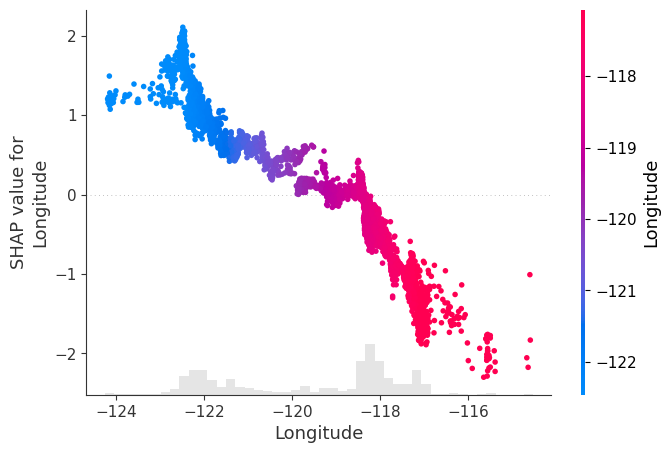

In [13]:
for col in columns:
    shap.plots.scatter(shap_values[:, col], color=shap_values[:, col])

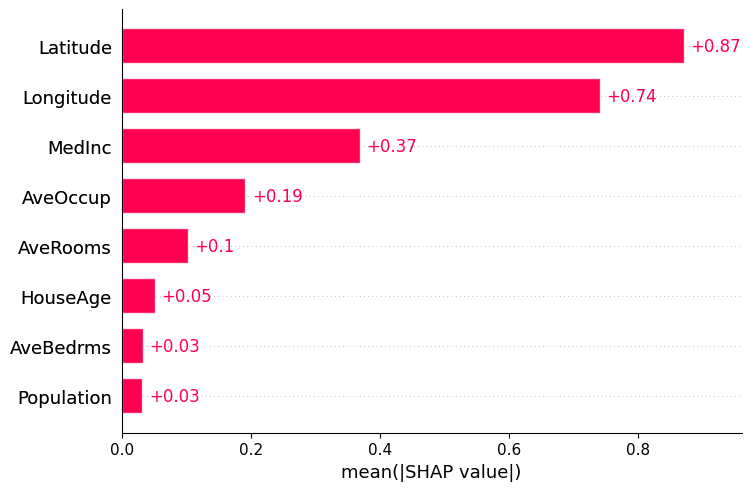

In [14]:
shap.plots.bar(shap_values)

Ce graphique montre qu’en moyenne, les caractéristiques **Latitude**, **Longitude**, **MedInc**, **AveOccup**, **AveRooms**, **HouseAge**, **Population**, et **AveBedrms** contribuent respectivement, en valeur absolue, à hauteur de **0,87**, **0,74**, **0,37**, **0,19**, **0,10**, **0,05**, **0,03**, et **0,03** à la prédiction du modèle par rapport à la baseline.Ces résultats confirment l’importance relative des variables identifiées précédemment, avec une influence majeure des trois premières caractéristiques (**Latitude**, **Longitude**, et **MedInc**) et une contribution plus marginale des autres.

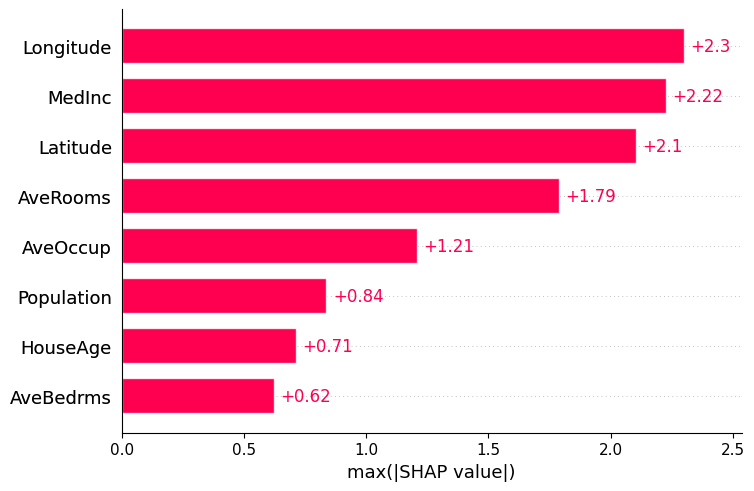

In [15]:
shap.plots.bar(shap_values.abs.max(0))

Ce graphique illustre que les caractéristiques **Latitude**, **Longitude**, **MedInc**, **AveOccup**, **AveRooms**, **HouseAge**, **Population**, et **AveBedrms** contribuent, en valeur absolue, à hauteur de **2.3**, **2.22**, **2.1**, **1.79**, **1.21**, **0.84**, **0.71**, et **0.62** respectivement à la prédiction du modèle par rapport à la baseline.

**Interprétation** :
- Les caractéristiques **Latitude**, **Longitude**, et **MedInc** ont les contributions les plus élevées, avec des valeurs proches de **2**, ce qui suggère qu'elles jouent un rôle majeur dans la détermination des prédictions du modèle. En particulier, cela indique que la **localisation géographique** (latitude et longitude) et le **revenu médian** influencent de manière significative la valeur prédite des maisons.
- **AveOccup**, **AveRooms**, et **HouseAge** montrent des contributions modérées, impliquant qu’elles sont également importantes, mais dans une moindre mesure. Leur impact est notable, mais moins central comparé aux premières caractéristiques.
- **Population** et **AveBedrms** ont les contributions les plus faibles, mais leur effet reste non négligeable. Ces variables semblent avoir un impact plus subtil sur la prédiction finale, sans être aussi influentes que celles liées à la géographie et au revenu.

En résumé, la géographie et le revenu médian sont les facteurs clés qui déterminent principalement les prédictions du modèle, tandis que les autres caractéristiques contribuent de manière plus modérée. 

**Observont les shap value pour quelques observation**

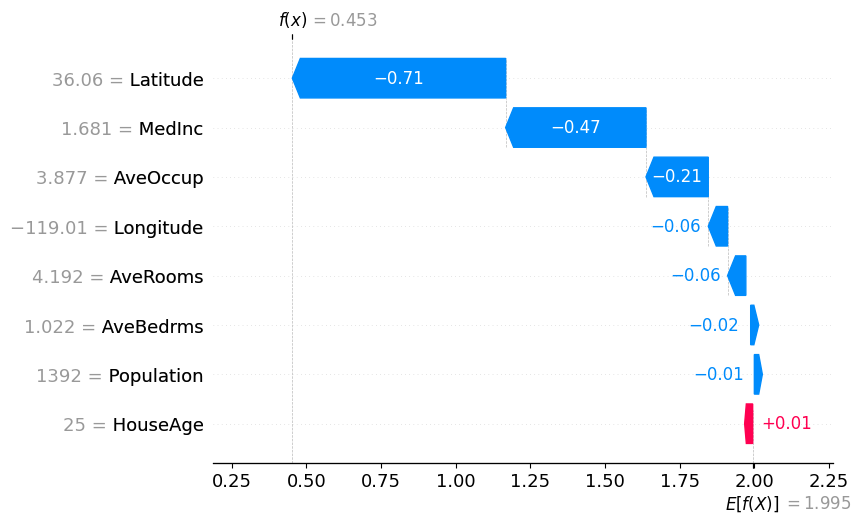

In [16]:
shap.plots.waterfall(shap_values[0], max_display=14)

**Latitude (36.06)** : impact -0.71, la latitude la plus méridionale réduit fortement la valeur prédite, reflétant des zones à prix plus bas.

**MedInc (1.681)** : impact -0.47, revenu médian faible qui contribue à une baisse significative de la prédiction.

**AveOccup (3.877)** : impact -0.21, densité d’occupation modérée qui réduit légèrement la valeur prédite.

**Longitude (-119.01)** : impact -0.06, légère diminution de la valeur prédite, correspondant à une localisation éloignée de la côte.

**AveRooms (4.192)** : impact -0.06, nombre moyen de pièces moyen qui a un effet faible sur la prédiction.

**AveBedrms (1.022)** : impact -0.02, influence très faible, le nombre de chambres n’affecte quasiment pas la prédiction.

**Population (1392)** : impact -0.01, population presque sans effet sur la valeur prédite.

**HouseAge (25)** : impact +0.01, âge moyen des maisons, seul facteur positif, mais effet minime sur la prédiction.

**Synthèse** : Les facteurs dominants qui réduisent la prédiction sont **Latitude** et **MedInc**. **HouseAge** augmente légèrement la prédiction. Les autres variables ont des impacts faibles ou négligeables.
